# 10. Low wind effect: petal modes on a spider-cut pupil

Under low wind, a telescope's spider arms cool radiatively below the ambient air and the air downstream of each vane does not get swept away. Each spider-bounded region of the pupil then sees its own optical path: a step across every vane plus a gradient within the region. This is the **low wind effect** (LWE), first characterised on VLT/SPHERE, routinely seen on Subaru/SCExAO, and one instance of the broader **island effect** that any fragmented pupil suffers.

The standard modal description is *the first three Zernike modes over each spider-bounded quadrant* — piston, tip and tilt per petal, 12 modes on a 4-vane pupil, of rank 11 once the unobservable mean piston is removed (N'Diaye et al. 2018; Sauvage et al. 2016; Vievard et al. 2019). The ELT petal-mode literature keeps piston only, one scalar per petal with the mean removed (Levraud et al. 2024). Typical on-sky amplitudes:

| Telescope | Amplitude | Source |
|---|---|---|
| VLT/SPHERE | 600–800 nm peak-to-valley of path; quadrant steps up to ~500 nm; a 1 K air step ≈ 100 nm | Sauvage 2016, Milli 2018 |
| Subaru/SCExAO | 300–600 nm petal steps; 10–20 % of nights below ~3 m/s wind | Vievard 2019, Deo 2022 |
| ELT (predicted) | ~0.8–1 µm around the spiders | Levraud 2024 |

`telescope-sim` models this with two existing pieces: the aperture's `segmentation:` block finds the petals in any built pupil by connected-components labeling, and the `segmented_ptt` corrector puts piston, tip and tilt on each of them. Here we run it on the real SCExAO/VAMPIRES F750 model from `instruments/scexao_vampires/` (the 2024 pupil by Miles Lucas: four off-centre spiders, two dead-actuator masks, one of them with its own thin support vane).

connected regions found: 5 → petals kept: 4
  merged a 3970-px fragment at (-1.29, -2.11) m into petal 0
actuators per petal: 3 → 12 total; actuators.shape = (4, 3)


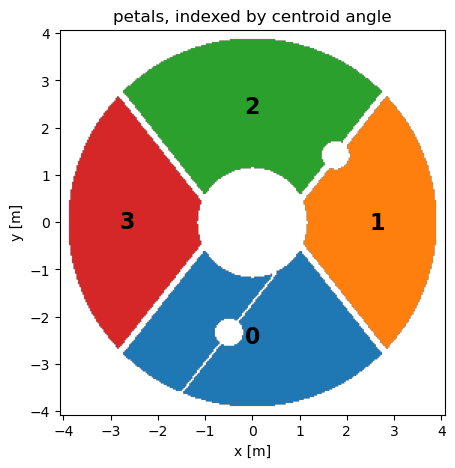

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
import hcipy
from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build
from telescope_sim.helpers.diagnostics import plot_opd_and_psfs

INSTRUMENT = Path('instruments/scexao_vampires')
base = yaml.safe_load((INSTRUMENT / 'vampires_f750_2024.yaml').read_text())
base['aperture']['module'] = str(INSTRUMENT / base['aperture']['module'])

# Partition the pupil into its four petals. The 2024 pupil labels as
# FIVE connected regions (the second dead-actuator mask's support
# vane cuts one quadrant in two); the smaller piece is merged into
# its nearest petal and the merge is recorded.
base['aperture']['segmentation'] = {'n_segments': 4}

# Per-petal piston/tip/tilt as an imposed disturbance. Caller unit:
# 1 = 100 nm of mirror surface = 200 nm of optical path.
base['correctors'] = {
    'petals': {
        'type': 'segmented_ptt',
        'piston_scale': 1.0e-7,
        'tip_tilt_scale': 1.0e-7,
        'wavefront_role': 'impose',
        'target_strategy': 'actuators',
        'target': True,
    },
}
base['corrector_chain'] = ['petals']
# Matched-filter Strehl over a 3 λ/D core (λ/D ≈ 20 mas at 748 nm / 7.79 m).
base['strehl_method'] = 'matched_filter'
base['strehl_core_rad'] = 3.0e-7

sim = build(SimConfig.model_validate(base))
petals = sim.correctors['petals']
seg = sim.aperture.metadata['segmentation']
print('connected regions found:', seg['n_raw_regions'],
      '→ petals kept:', seg['n_segments'])
for rec in seg['merge_info']:
    cx, cy = rec['fragment_centroid']
    print(f"  merged a {rec['fragment_size_px']}-px fragment at "
          f"({cx:+.2f}, {cy:+.2f}) m into petal {rec['segment_index']}")
print('actuators per petal: 3 →', petals.n_actuators, 'total;',
      'actuators.shape =', petals.actuators.shape)

shape = sim.aperture.field.grid.shape
label_img = np.zeros(shape)
for i, mask in enumerate(sim.aperture.segments):
    label_img += (i + 1) * np.asarray(mask).reshape(shape)
extent = sim.aperture.field.grid.x.min(), sim.aperture.field.grid.x.max()
plt.figure(figsize=(5, 5))
plt.imshow(np.ma.masked_equal(label_img, 0), origin='lower', cmap='tab10',
           extent=(*extent, *extent), vmin=0.5, vmax=10.5)
for i, (cx, cy) in enumerate(sim.aperture.segment_coords):
    plt.text(cx, cy, str(i), ha='center', va='center', fontsize=16, weight='bold')
plt.title('petals, indexed by centroid angle')
plt.xlabel('x [m]'); plt.ylabel('y [m]')
plt.show()


## One petal at a time

Petal indices follow the polar angle of each region's centroid, so on this pupil 0 is the bottom petal, 1 the right, 2 the top, 3 the left. A piston on one petal produces a roughly radial halo asymmetry; a tip on the same petal produces a different, direction-keyed one. Equal pistons on all petals leave the PSF untouched — the mean piston is unobservable, which is why the 12-mode basis has rank 11.

Strehl at rest:          1.000
Strehl, petal-1 piston:  0.498
Strehl, petal-1 tip:     0.938
Strehl, equal pistons:   1.000  (image differs from rest by 7.8e-16)


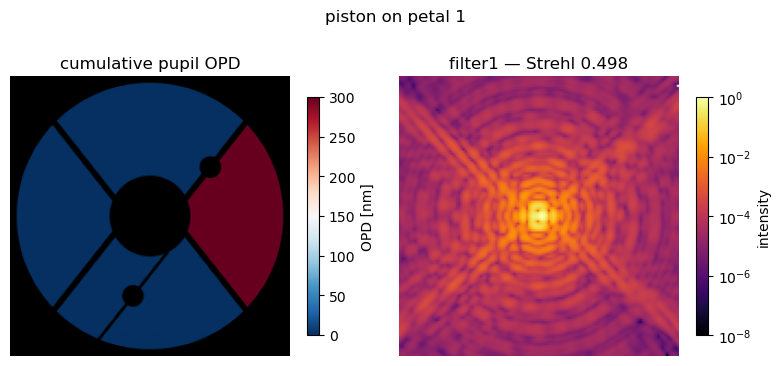

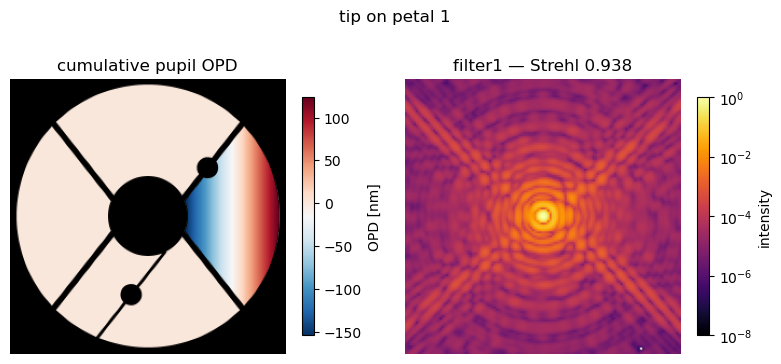

In [2]:
rest = sim.sample(meas_strehl=True, meas_pupil_opd=True)

piston = np.zeros((4, 3)); piston[1, 0] = 1.5      # 300 nm of path on petal 1
tip = np.zeros((4, 3)); tip[1, 1] = 0.5            # a slope across petal 1
equal = np.zeros((4, 3)); equal[:, 0] = 1.5        # the same piston on every petal

out_p = sim.sample({'petals': piston}, meas_strehl=True, meas_pupil_opd=True)
out_t = sim.sample({'petals': tip}, meas_strehl=True, meas_pupil_opd=True)
out_e = sim.sample({'petals': equal}, meas_strehl=True, meas_pupil_opd=True)
print(f"Strehl at rest:          {rest['strehls']['filter1']:.3f}")
print(f"Strehl, petal-1 piston:  {out_p['strehls']['filter1']:.3f}")
print(f"Strehl, petal-1 tip:     {out_t['strehls']['filter1']:.3f}")
print(f"Strehl, equal pistons:   {out_e['strehls']['filter1']:.3f}  "
      f"(image differs from rest by "
      f"{np.max(np.abs(out_e['images']['psf'] - rest['images']['psf'])):.1e})")

plot_opd_and_psfs(sim, out_p, suptitle='piston on petal 1')
plot_opd_and_psfs(sim, out_t, suptitle='tip on petal 1')
plt.show()


## An LWE-scale state

A SPHERE-like episode: ~600 nm peak-to-valley of path across the petals plus some tilt inside each. Milli et al. (2018) calibrate ~200 nm RMS of LWE path to roughly 60 % Strehl — in the H band. VAMPIRES observes at 748 nm, where the same path error is more than twice the phase, so the matched-filter Strehl here is far lower: the low wind effect is a visible-light catastrophe before it is an infrared nuisance.

path PV 749 nm, RMS 228 nm, Strehl 0.191


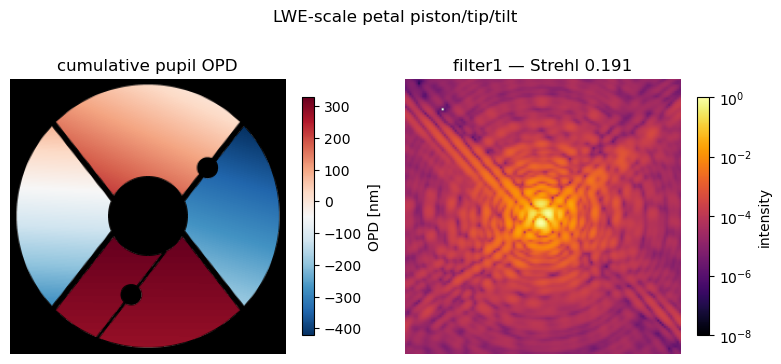

In [3]:
rng = np.random.default_rng(7)
lwe = np.zeros((4, 3))
lwe[:, 0] = [1.5, -1.5, 0.5, -0.5]          # pistons: 600 nm PV of path
lwe[:, 1:] = rng.normal(scale=0.25, size=(4, 2))  # tip/tilt per petal

out_lwe = sim.sample({'petals': lwe}, meas_strehl=True, meas_pupil_opd=True)
opd = np.asarray(out_lwe['pupil_opd'])[np.asarray(sim.aperture.field) > 0]
print(f"path PV {1e9 * (opd.max() - opd.min()):.0f} nm, "
      f"RMS {1e9 * opd.std():.0f} nm, "
      f"Strehl {out_lwe['strehls']['filter1']:.3f}")
plot_opd_and_psfs(sim, out_lwe, suptitle='LWE-scale petal piston/tip/tilt')
plt.show()


## Correcting it with a continuous DM

Append a `fourier` DM (46 smooth cosine/sine modes) in the `actuate` role with `target_strategy: actuators_plus_residual_fit`. Its echo is then the least-squares projection of everything upstream onto its own basis — the supervision signal an ML controller would train on — and applying the negated echo is the best correction that DM can make. The smooth part of the disturbance goes away; what remains is the step at every vane that no smooth basis can follow. That is the fitting error the SPHERE and SCExAO correction papers describe at the spider edges (Wilby et al. 2018, N'Diaye et al. 2018).

before: path RMS   228 nm, Strehl 0.191
after : path RMS    62 nm, Strehl 0.794


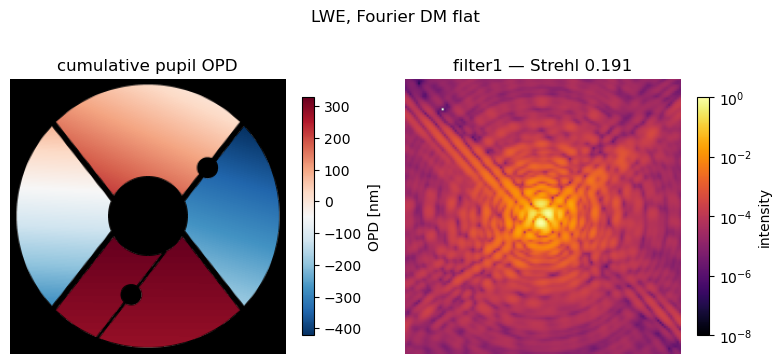

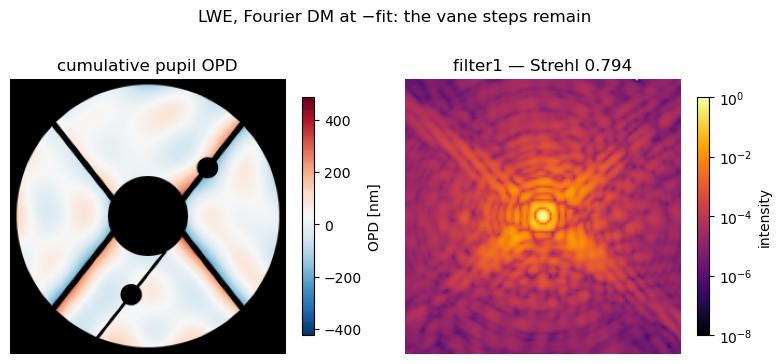

In [4]:
corr_cfg = yaml.safe_load(yaml.safe_dump(base))
corr_cfg['correctors']['petals']['target_strategy'] = 'none'
corr_cfg['correctors']['petals']['target'] = False
corr_cfg['correctors']['fourier_dm'] = {
    'type': 'fourier',
    'n_axis': 6,
    'actuate_scale': 1.0e-7,
    'wavefront_role': 'actuate',
    'target_strategy': 'actuators_plus_residual_fit',
    'target': True,
}
corr_cfg['corrector_chain'] = ['petals', 'fourier_dm']
corr_sim = build(SimConfig.model_validate(corr_cfg))
n_fourier = corr_sim.correctors['fourier_dm'].n_actuators

# Pass 1: disturbance on, DM flat → the echo is the DM's best fit of it.
pre = corr_sim.sample({'petals': lwe, 'fourier_dm': np.zeros(n_fourier)},
                      meas_strehl=True, meas_pupil_opd=True)
y_fit = pre['actuations']['fourier_dm']
# Pass 2: apply the negated fit — the controller's move.
post = corr_sim.sample({'petals': lwe, 'fourier_dm': -y_fit},
                       meas_strehl=True, meas_pupil_opd=True)

lit = np.asarray(sim.aperture.field) > 0
for name, out in [('before', pre), ('after ', post)]:
    o = np.asarray(out['pupil_opd'])[lit]
    print(f"{name}: path RMS {1e9 * o.std():5.0f} nm, "
          f"Strehl {out['strehls']['filter1']:.3f}")
plot_opd_and_psfs(corr_sim, pre, suptitle='LWE, Fourier DM flat')
plot_opd_and_psfs(corr_sim, post,
                  suptitle='LWE, Fourier DM at −fit: the vane steps remain')
plt.show()


## Petal pistons only, and a note on wrapping

`piston_only: true` reduces the corrector to one piston per petal — the basis the ELT island-effect work uses. The actuator state becomes `(n_segments,)`, tip and tilt are held at zero, and `fit_surface` returns the piston column; a pupil with six spider arms simply takes `n_segments: 6`.

Ground truth here is unwrapped path in metres, but an image only sees differential piston modulo the wavelength: a petal shifted by exactly one wave of path is invisible monochromatically, and across a 6 % band it is still nearly so. That ±λ/2 capture range is why the petal-sensing literature reaches for multi-wavelength measurements, and why a simulator should keep the unwrapped state and let the band decide what is observable.

In [5]:
po_cfg = yaml.safe_load(yaml.safe_dump(base))
po_cfg['correctors']['petals']['piston_only'] = True
po_sim = build(SimConfig.model_validate(po_cfg))
pistons = lwe[:, 0]
out_po = po_sim.sample({'petals': pistons}, meas_strehl=True)
same = sim.sample({'petals': np.column_stack([pistons, np.zeros(4), np.zeros(4)])},
                  meas_strehl=True)
print('n_actuators:', po_sim.correctors['petals'].n_actuators,
      '| echo shape:', out_po['actuations']['petals'].shape,
      '| identical to full PTT with zero tip/tilt:',
      np.array_equal(out_po['images']['psf'], same['images']['psf']))

# One wave of path on a petal at the central wavelength: invisible
# monochromatically, and nearly so across this band.
lam = 0.748e-6
one_wave = np.array([lam / 2 / 1.0e-7, 0, 0, 0])   # surface = path / 2
wrapped = po_sim.sample({'petals': one_wave}, meas_strehl=True)
print('one wave of path on petal 0, broadband Strehl:',
      f"{wrapped['strehls']['filter1']:.3f}")


n_actuators: 4 | echo shape: (4,) | identical to full PTT with zero tip/tilt: True
one wave of path on petal 0, broadband Strehl: 0.997


## The same chain on the JAX backend

Segmentation runs once in numpy and the corrector exposes a mirror surface, so nothing changes for `backend: jax`: the same YAML builds, the images agree to round-off, and `forward_fn` / `sample_batch` carry the petal state as ordinary differentiable inputs.

In [6]:
jax_sim = build(SimConfig.model_validate(corr_cfg), backend='jax')
post_jax = jax_sim.sample({'petals': lwe, 'fourier_dm': -y_fit}, meas_strehl=True)
diff = np.max(np.abs(post_jax['images']['psf'] - post['images']['psf']))
print(f"max |jax − hcipy| on the normalised image: {diff:.1e}")
fwd = jax_sim.forward_fn()
print('forward_fn inputs:', fwd.n_actuators)


max |jax − hcipy| on the normalised image: 3.6e-15


forward_fn inputs: {'petals': 12, 'fourier_dm': 46}
